# Logistic Regression — Perlidae and Helicopsychidae

Binary logistic regression models for the presence/absence of the two bioindicator
taxa (*Plecoptera: Perlidae* and *Trichoptera: Helicopsychidae*) in the Cali River,
validated with leave-one-out cross-validation (LOOCV).

## 1. Introduction

Two single-predictor logistic regression models are fitted, one per bioindicator
taxon. Candidate predictors are screened by AIC over a small PCA-derived set;
`DBO5` (BOD₅) is the selected predictor for both taxa. Each model is evaluated under
LOOCV, and both calibration (training-fold) and validation (held-out) metrics are
reported. Class imbalance is handled with balanced class weights.

## 2. Dependencies and Data Loading

The macroinvertebrate dataset (n = 18) provides the physicochemical predictors and
the binary presence/absence of `Perlidae` and `Trichoptera` (Helicopsychidae).

In [1]:
# Imports and global plotting style
import numpy as np
import pandas as pd
import statsmodels.api as sm
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import (confusion_matrix, classification_report, cohen_kappa_score,
                             precision_recall_fscore_support, accuracy_score)
import warnings
warnings.filterwarnings("ignore")
sns.set_style('whitegrid')

In [2]:
# Load the macroinvertebrate dataset (relative path)
df = pd.read_excel("../../data/DB - Macroinvertebrados.xlsx")
df.columns = df.columns.str.strip()
print("Shape:", df.shape)
print("Perlidae +/-:", df['Perlidae'].value_counts().to_dict())
print("Helicopsychidae (Trichoptera) +/-:", df['Trichoptera'].value_counts().to_dict())

Shape: (18, 24)
Perlidae +/-: {0: 12, 1: 6}
Helicopsychidae (Trichoptera) +/-: {0: 15, 1: 3}


## 3. Predictor Selection

Candidate predictors (`DBO5`, `Dureza`, `Caudal`) come from a 3-variable PCA. All
subsets are fitted as binomial GLMs and ranked by AIC. The single predictor `DBO5`
gives the lowest AIC and is used for both taxa.

In [3]:
# Exhaustive AIC-based subset selection for a binomial GLM (illustrated on Perlidae)
def select_model(dataframe, predictors, response):
    best_aic, best_combination = np.inf, None
    for L in range(1, len(predictors) + 1):
        for subset in combinations(predictors, L):
            X_subset = sm.add_constant(dataframe[list(subset)])
            result = sm.GLM(dataframe[response], X_subset, family=sm.families.Binomial()).fit()
            print(f"predictors {subset}: AIC = {result.aic:.3f}")
            if result.aic < best_aic:
                best_aic, best_combination = result.aic, subset
    print(f"Best subset: {best_combination} (AIC = {best_aic:.3f})")
    return best_combination

candidate_predictors = ['DBO5', 'Dureza', 'Caudal']
select_model(df, candidate_predictors, ['Perlidae'])
selected_predictor = 'DBO5'
print("Selected predictor for both taxa:", selected_predictor)

predictors ('DBO5',): AIC = 20.636
predictors ('Dureza',): AIC = 22.769
predictors ('Caudal',): AIC = 26.070
predictors ('DBO5', 'Dureza'): AIC = 21.925
predictors ('DBO5', 'Caudal'): AIC = 22.104
predictors ('Dureza', 'Caudal'): AIC = 24.411
predictors ('DBO5', 'Dureza', 'Caudal'): AIC = 23.507
Best subset: ('DBO5',) (AIC = 20.636)
Selected predictor for both taxa: DBO5


## 4. Model Definition

A standardised single-predictor logistic model with an L2 penalty and
`class_weight='balanced'`. Balancing is used because both taxa are imbalanced
(Perlidae 6/18 present; Helicopsychidae 3/18 present); without it the model would
default to predicting the majority class (absence). This follows established practice
for imbalanced ecological presence/absence data (Kuhn & Johnson, 2013).

In [4]:
# LOOCV routine returning validation (held-out) and calibration (training) predictions
def logistic_loocv(y_col):
    X = df[[selected_predictor]].values
    y = df[y_col].values
    X_scaled = StandardScaler().fit_transform(X)
    model = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                               random_state=42, class_weight='balanced')
    loo = LeaveOneOut()
    yt_val, yp_val, yt_cal, yp_cal = [], [], [], []
    for tr, te in loo.split(X_scaled):
        model.fit(X_scaled[tr], y[tr])
        yt_val.append(int(y[te][0])); yp_val.append(int(model.predict(X_scaled[te])[0]))
        yt_cal.extend(y[tr].tolist()); yp_cal.extend(model.predict(X_scaled[tr]).tolist())
    return {'yt_val': yt_val, 'yp_val': yp_val, 'yt_cal': yt_cal, 'yp_cal': yp_cal}

# Standardised confusion-matrix plotter: figsize (10, 7), Blues, saved to outputs/ and shown
def plot_confusion(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 16},
                xticklabels=['Absent', 'Present'], yticklabels=['Absent', 'Present'])
    plt.title(title, fontsize=14); plt.xlabel('Predicted', fontsize=12); plt.ylabel('Observed', fontsize=12)
    plt.tight_layout(); plt.savefig(f"../../outputs/{filename}", dpi=300); plt.show()

# Fit LOOCV for both taxa
loocv = {'Perlidae': logistic_loocv('Perlidae'),
         'Helicopsychidae': logistic_loocv('Trichoptera')}
print("LOOCV complete for both taxa.")

LOOCV complete for both taxa.


## 5. Evaluation — Calibration

Calibration metrics aggregate the training-fold predictions across all LOOCV folds.

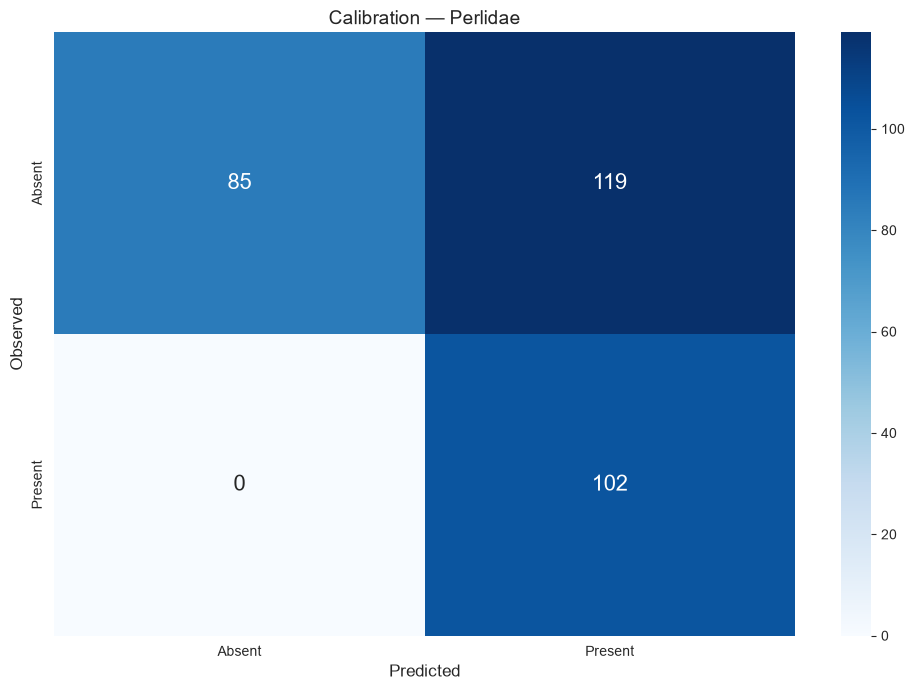

              precision    recall  f1-score   support

      Absent       1.00      0.42      0.59       204
     Present       0.46      1.00      0.63       102

    accuracy                           0.61       306
   macro avg       0.73      0.71      0.61       306
weighted avg       0.82      0.61      0.60       306

Cohen's Kappa (calibration): 0.323


In [5]:
# Perlidae — calibration confusion matrix, classification report, Cohen's kappa
res = loocv['Perlidae']
plot_confusion(res['yt_cal'], res['yp_cal'], 'Calibration — Perlidae',
               'logistic_perlidae_confusion_matrix_calibration.png')
print(classification_report(res['yt_cal'], res['yp_cal'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(res['yt_cal'], res['yp_cal']):.3f}")

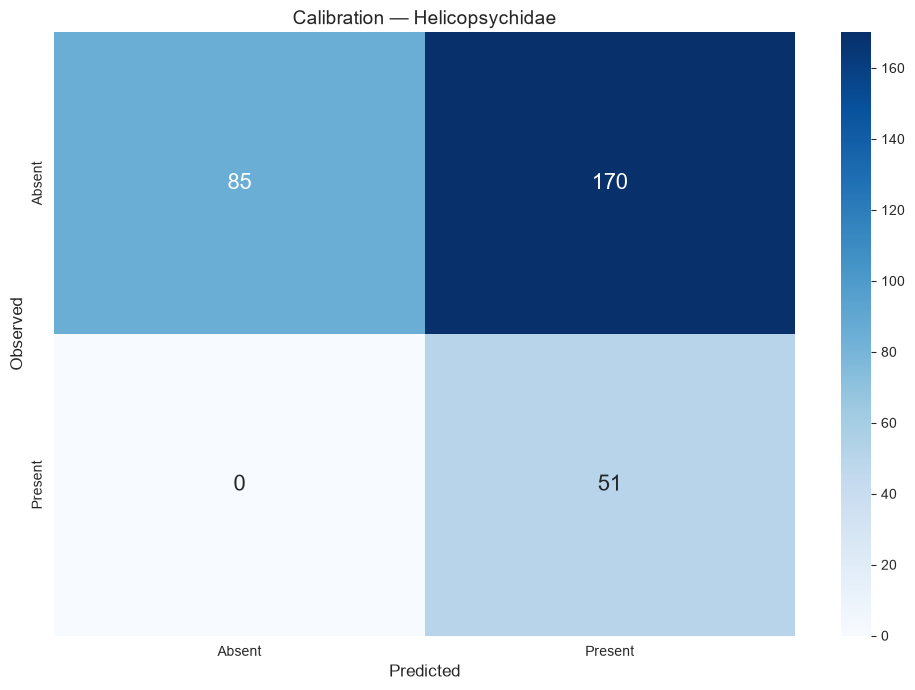

              precision    recall  f1-score   support

      Absent       1.00      0.33      0.50       255
     Present       0.23      1.00      0.38        51

    accuracy                           0.44       306
   macro avg       0.62      0.67      0.44       306
weighted avg       0.87      0.44      0.48       306

Cohen's Kappa (calibration): 0.143


In [6]:
# Helicopsychidae — calibration confusion matrix, classification report, Cohen's kappa
res = loocv['Helicopsychidae']
plot_confusion(res['yt_cal'], res['yp_cal'], 'Calibration — Helicopsychidae',
               'logistic_helicopsychidae_confusion_matrix_calibration.png')
print(classification_report(res['yt_cal'], res['yp_cal'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (calibration): {cohen_kappa_score(res['yt_cal'], res['yp_cal']):.3f}")

## 6. Evaluation — Validation (LOOCV)

Validation metrics use the held-out observation from each fold — the honest estimate
of out-of-sample performance.

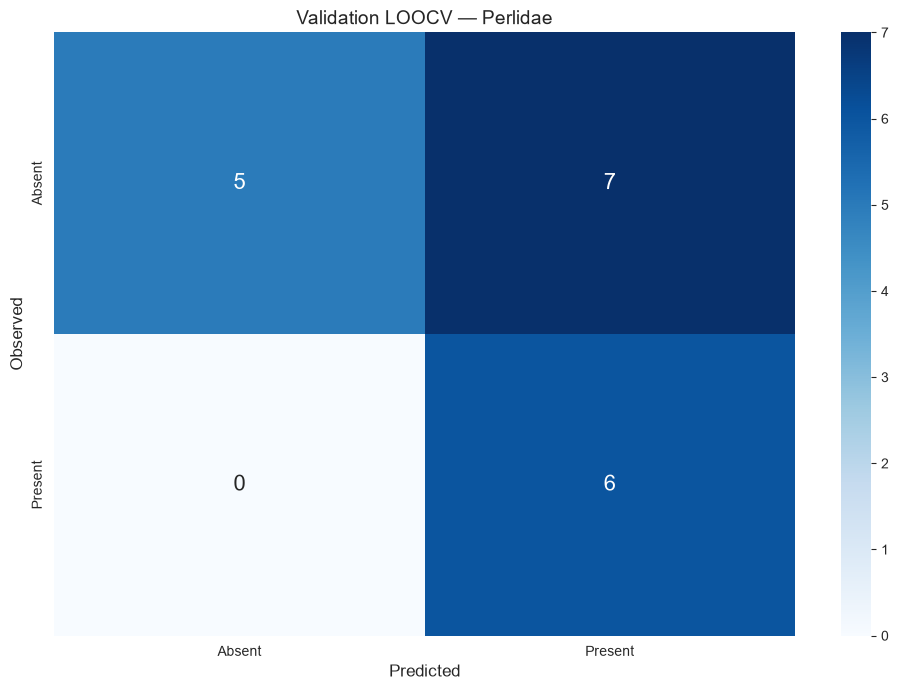

              precision    recall  f1-score   support

      Absent       1.00      0.42      0.59        12
     Present       0.46      1.00      0.63         6

    accuracy                           0.61        18
   macro avg       0.73      0.71      0.61        18
weighted avg       0.82      0.61      0.60        18

Cohen's Kappa (validation): 0.323


In [7]:
# Perlidae — validation confusion matrix, classification report, Cohen's kappa
res = loocv['Perlidae']
plot_confusion(res['yt_val'], res['yp_val'], 'Validation LOOCV — Perlidae',
               'logistic_perlidae_confusion_matrix_validation.png')
print(classification_report(res['yt_val'], res['yp_val'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (validation): {cohen_kappa_score(res['yt_val'], res['yp_val']):.3f}")

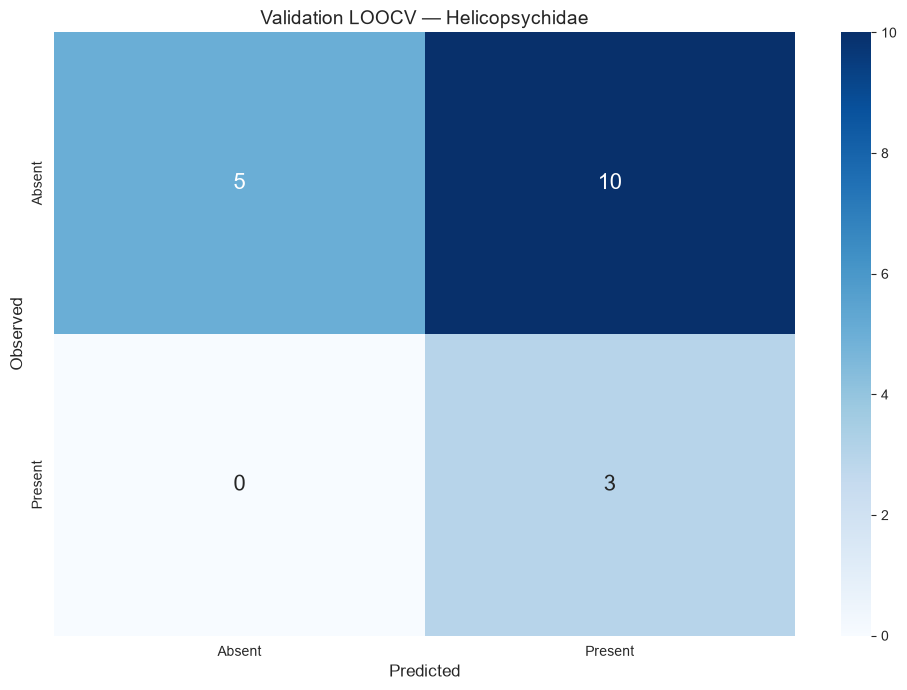

              precision    recall  f1-score   support

      Absent       1.00      0.33      0.50        15
     Present       0.23      1.00      0.38         3

    accuracy                           0.44        18
   macro avg       0.62      0.67      0.44        18
weighted avg       0.87      0.44      0.48        18

Cohen's Kappa (validation): 0.143


In [8]:
# Helicopsychidae — validation confusion matrix, classification report, Cohen's kappa
res = loocv['Helicopsychidae']
plot_confusion(res['yt_val'], res['yp_val'], 'Validation LOOCV — Helicopsychidae',
               'logistic_helicopsychidae_confusion_matrix_validation.png')
print(classification_report(res['yt_val'], res['yp_val'], labels=[0, 1],
                            target_names=['Absent', 'Present'], zero_division=0))
print(f"Cohen's Kappa (validation): {cohen_kappa_score(res['yt_val'], res['yp_val']):.3f}")

### Note on Helicopsychidae performance

With only 3 presences of 18 (17 %), LOOCV cannot reliably estimate minority-class
generalisation. The validation results for this taxon should be read with caution;
Cohen's κ is the most informative single metric under such imbalance.

## 8. Visualisation

Fitted logistic probability curves (presence probability vs BOD₅) for each taxon,
refitted on the full sample for display.

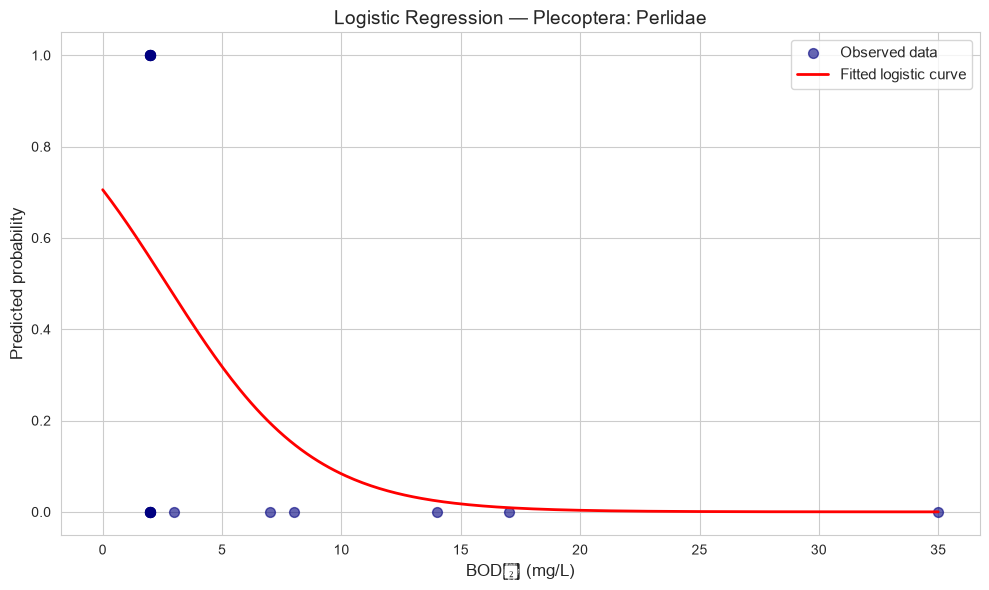

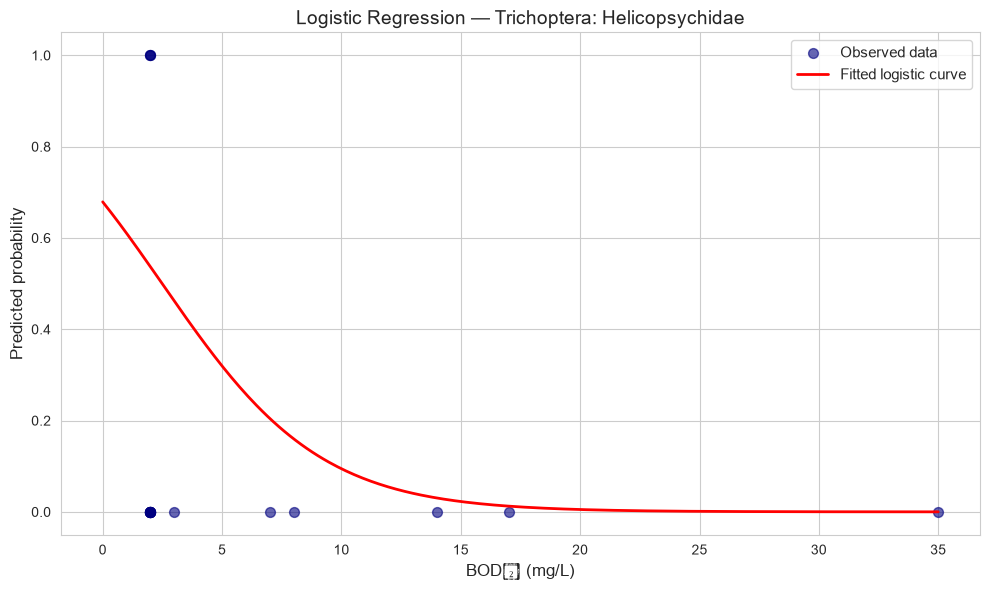

In [9]:
# Helper: fit a single-predictor logistic model on raw DBO5 and plot the fitted curve
def plot_logistic_curve(y_col, taxon, filename):
    X = df[[selected_predictor]].values
    y = df[y_col].values
    model = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000,
                               random_state=42, class_weight='balanced').fit(X, y)
    b0 = model.intercept_[0]; b1 = model.coef_[0][0]
    x_grid = np.linspace(0, df[selected_predictor].max(), 300)
    p_grid = 1 / (1 + np.exp(-(b0 + b1 * x_grid)))
    plt.figure(figsize=(10, 6))
    plt.scatter(df[selected_predictor], y, color='navy', alpha=0.6, s=50, label='Observed data')
    plt.plot(x_grid, p_grid, color='red', linewidth=2, label='Fitted logistic curve')
    plt.title(f'Logistic Regression — {taxon}', fontsize=14)
    plt.xlabel('BOD₅ (mg/L)', fontsize=12); plt.ylabel('Predicted probability', fontsize=12)
    plt.legend(fontsize=11)
    plt.tight_layout(); plt.savefig(f"../../outputs/{filename}", dpi=300); plt.show()

plot_logistic_curve('Perlidae', 'Plecoptera: Perlidae', 'logistic_curve_perlidae.png')
plot_logistic_curve('Trichoptera', 'Trichoptera: Helicopsychidae', 'logistic_curve_helicopsychidae.png')

In [10]:
# Export validation metrics for the master results table
rows = []
for taxon in ['Perlidae', 'Helicopsychidae']:
    res = loocv[taxon]
    p, r, f, _ = precision_recall_fscore_support(res['yt_val'], res['yp_val'], labels=[0, 1],
                                                 average='macro', zero_division=0)
    rows.append({'target': taxon, 'technique': 'Logistic regression', 'validation': 'LOOCV', 'n': 18,
                 'precision': round(p, 3), 'recall': round(r, 3), 'f1': round(f, 3),
                 'accuracy': round(accuracy_score(res['yt_val'], res['yp_val']), 3),
                 'kappa': round(cohen_kappa_score(res['yt_val'], res['yp_val']), 3)})
pd.DataFrame(rows).to_csv("../../outputs/metrics_logistic.csv", index=False)
print("Saved outputs/metrics_logistic.csv")
print(pd.DataFrame(rows).to_string(index=False))

Saved outputs/metrics_logistic.csv
         target           technique validation  n  precision  recall    f1  accuracy  kappa
       Perlidae Logistic regression      LOOCV 18      0.731   0.708 0.610     0.611  0.323
Helicopsychidae Logistic regression      LOOCV 18      0.615   0.667 0.438     0.444  0.143


## 9. Limitations

- **Very small sample** (n = 18) with strong class imbalance (Helicopsychidae 3/18
  present); validation metrics have wide uncertainty and one observation can move a
  score.
- **Single predictor.** AIC selects `DBO5` alone; richer relationships cannot be
  captured by a one-variable logistic model, and the wide coefficient standard errors
  reflect quasi-separation in this small sample.
- **Spatial non-independence.** Stations lie along one river, so LOOCV folds are not
  fully independent.
- **Class balancing.** `class_weight='balanced'` improves minority-class recall but
  can inflate false positives, particularly for the rare Helicopsychidae taxon.